<a href="https://colab.research.google.com/github/DS-Ninja/Dmitrij-Levyj/blob/Main/Study%20DS%20010%23%20-%20Simple%20Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---
---

<center>

#Study DS 7# - Area Plots, Histograms, and Bar Charts.

</center>

---




---

```
Author
Dmitrij Levyj | "Details Matter"
```



<center>

---

[![WhatsApp](https://img.shields.io/badge/Whatsapp-Blue?style=social&logo=Whatsapp)](https://call.whatsapp.com/voice/WAl0Hu47THhpnB7d2mimjf)
[![Messenger](https://img.shields.io/badge/Messenger-Blue?style=social&logo=Messenger)](https://m.me/dimitrioespanol)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Blue?style=social&logo=linkedin)](https://www.linkedin.com/in/dmitrij-levyj)
[![GitHub](https://img.shields.io/badge/GitHub-Blue?style=social&logo=github)](https://github.com/DS-Ninja/Dmitrij-Levyj)
[![Kaggle](https://img.shields.io/badge/Kaggle-Blue?style=social&logo=kaggle)](https://www.kaggle.com/dmitrijlevyj)
[![Tableau](https://img.shields.io/badge/Tableau-Blue?style=social&logo=Tableau)](https://public.tableau.com/app/profile/dmitrij.levyj)

</center>











---

##**Table of Contents**


* **1. Introduction**
* **2. Data preparation**
    * 2.1 Importing Libraries
    * 2.2 Downloading Data
* **3.Data Exploration**
* **4.Practice**
    * 4.1 Creating train and test dataset
    * 4.2 Train data distribution
    * 4.4 Plot outputs
    * 4.5 Evaluation


---


### 1.Introduction

We learn how to use the scikit-learn library to implement Simple linear regression. We download a dataset that is related to fuel consumption and Carbon dioxide emission of cars. Then, we split our data into training and test sets, create a model using a training set, evaluate your model using test set, and finally use model to predict unknown values.


## 2.Data preparation

### 2.1 Importing Libraries

In [29]:
# Install required libraries in Colab if not already installed
!pip install pandas matplotlib numpy scikit-learn

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import pylab as pl
%matplotlib inline

###2.2 Downloading Data

In [31]:
# File URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

# Load the CSV file directly into a Pandas DataFrame
df = pd.read_csv(url)

# Display the first few rows of the dataset
print(df.head())

   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4          AS6        Z                  12.1                  8.7   

   FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS  
0                   8.5                        33           196  
1                   


Understanding the Data

`FuelConsumption.csv`:
We have downloaded a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64)

- **MODELYEAR** e.g. 2014
- **MAKE** e.g. Acura
- **MODEL** e.g. ILX
- **VEHICLE CLASS** e.g. SUV
- **ENGINE SIZE** e.g. 4.7
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. A6
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 9.9
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 8.9
- **FUEL CONSUMPTION COMB (L/100 km)** e.g. 9.2
- **CO2 EMISSIONS (g/km)** e.g. 182   --> low --> 0


##3.Data Exploration

In [32]:
# summarize the data
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [33]:
#Let's select some features to explore more.
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


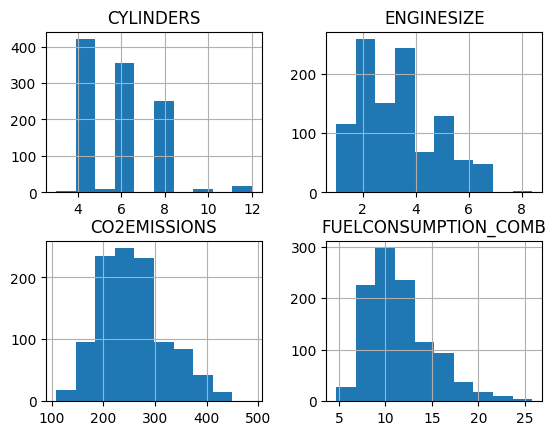

In [34]:
#Plot each of these features
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()
plt.show()

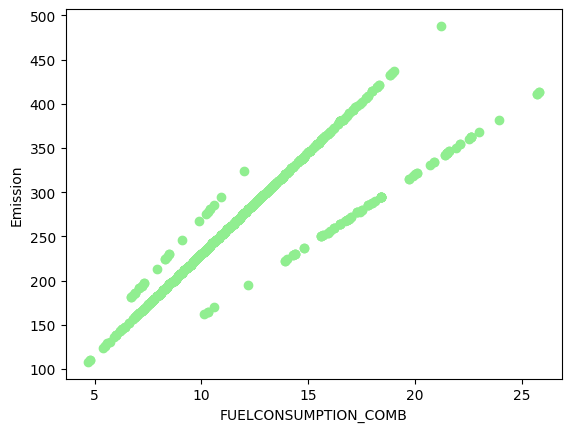

In [35]:
#Now, let's plot each of these features against the Emission, to see how linear their relationship is:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='lightgreen')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

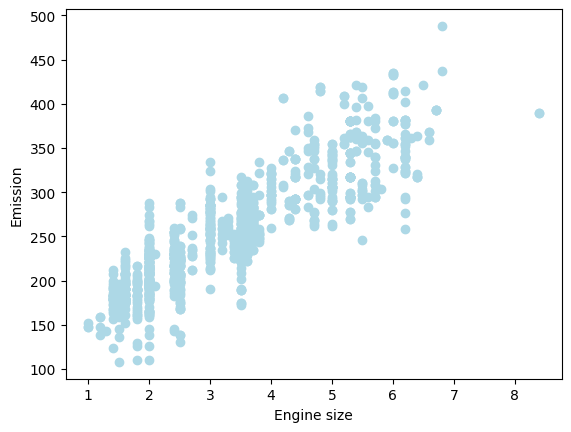

In [36]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS,  color='lightblue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

##4.Practice

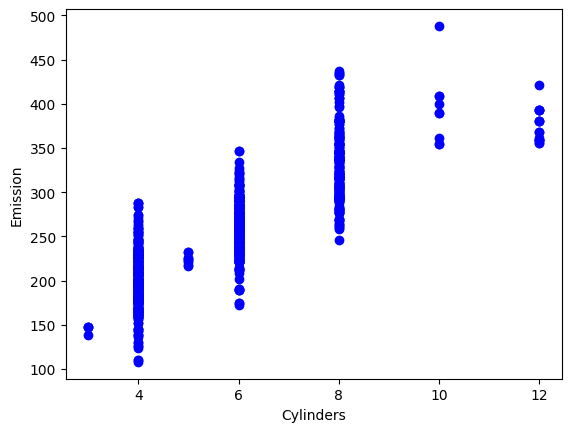

In [37]:
#Plot __CYLINDER__ vs the Emission, to see how linear is their relationship is:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.show()

###4.1 Creating train and test dataset
Train/Test Split involves splitting the dataset into training and testing sets that are mutually exclusive. After which, you train with the training set and test with the testing set.
This will provide a more accurate evaluation on out-of-sample accuracy because the testing dataset is not part of the dataset that have been used to train the model. Therefore, it gives us a better understanding of how well our model generalizes on new data.

This means that we know the outcome of each data point in the testing dataset, making it great to test with! Since this data has not been used to train the model, the model has no knowledge of the outcome of these data points. So, in essence, it is truly an out-of-sample testing.

Let's split our dataset into train and test sets. 80% of the entire dataset will be used for training and 20% for testing. We create a mask to select random rows using __np.random.rand()__ function:

In [38]:
# Creating a random mask for splitting the dataset
# Each row has an ~80% chance of being assigned to the training set
msk = np.random.rand(len(df)) < 0.8

# Assigning rows where the mask is True to the training set
train = cdf[msk]

# Assigning rows where the mask is False to the test set
test = cdf[~msk]

###4.2 Train data distribution

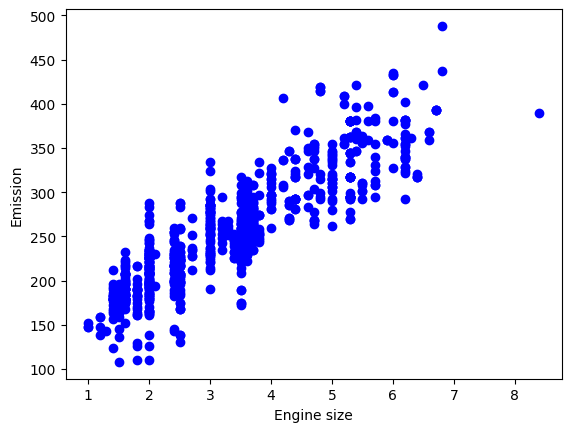

In [39]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

###4.3 Modeling
Using sklearn package to model data.

In [40]:
# Importing the Linear Regression Model
from sklearn import linear_model
regr = linear_model.LinearRegression()

# Preparing the Training Data
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

# Fitting the Model
regr.fit(train_x, train_y)

# Displaying the Coefficients and Intercept
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [[40.05262494]]
Intercept:  [122.96317377]


###4.4 Plot outputs

Text(0, 0.5, 'Emission')

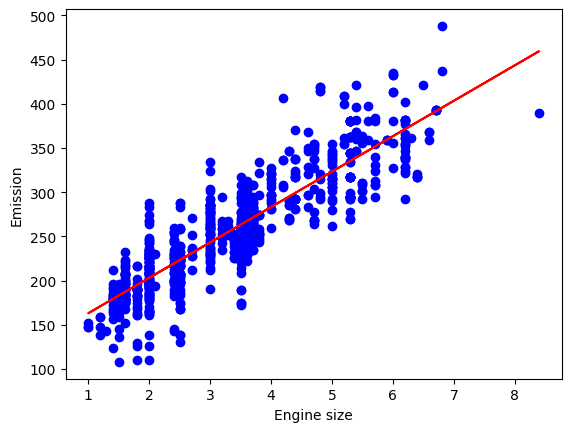

In [41]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

###4.5 Evaluation
We compare the actual values and predicted values to calculate the accuracy of a regression model. Evaluation metrics provide a key role in the development of a model, as it provides insight to areas that require improvement.

There are different model evaluation metrics, lets use MSE here to calculate the accuracy of our model based on the test set:
* Mean Absolute Error: It is the mean of the absolute value of the errors. This is the easiest of the metrics to understand since it’s just average error.

* Mean Squared Error (MSE): Mean Squared Error (MSE) is the mean of the squared error. It’s more popular than Mean Absolute Error because the focus is geared more towards large errors. This is due to the squared term exponentially increasing larger errors in comparison to smaller ones.

* Root Mean Squared Error (RMSE).

* R-squared is not an error, but rather a popular metric to measure the performance of your regression model. It represents how close the data points are to the fitted regression line. The higher the R-squared value, the better the model fits your data. The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse).


In [42]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y , test_y_) )

Mean absolute error: 24.78
Residual sum of squares (MSE): 1061.76
R2-score: 0.72
